In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

Debido a que no se encntro informacion especifica del subsidio para la ciudad seleccionada, se tiene que estimar el subsidio y por ende el consumo para todo el estado de Campeche

## Esto es para obtener el código para el estado

In [2]:
f = '../data/raw/catun_municipio/AGEEML_20258131423976_utf.csv'
ubica_geo = pd.read_csv(f, encoding="utf-8"
                       # usecols = ['folioviv','aire_acond','entidad','factor']
                      )
ubica_geo

,MAPA,CVE_ENT,NOM_ENT,NOM_ABR,CVE_MUN,NOM_MUN,CVE_CAB,NOM_CAB,POB_TOTAL,POB_MASCULINA,POB_FEMENINA,TOTAL DE VIVIENDAS HABITADAS
0,1001,1,Aguascalientes,Ags.,1,Aguascalientes,0001,Aguascalientes,948990,462073,486917,266942
1,1002,1,Aguascalientes,Ags.,2,Asientos,0001,Asientos,51536,25261,26275,12544
2,1003,1,Aguascalientes,Ags.,3,Calvillo,0001,Calvillo,58250,28563,29687,15556
3,1004,1,Aguascalientes,Ags.,4,Cosío,0001,Cosío,17000,8292,8708,3938
4,1005,1,Aguascalientes,Ags.,5,Jesús María,0001,Jesús María,129929,64219,65710,33229
...,...,...,...,...,...,...,...,...,...,...,...,...
2473,32054,32,Zacatecas,Zac.,54,Villa Hidalgo,0001,Villa Hidalgo,19446,9504,9942,4951
2474,32055,32,Zacatecas,Zac.,55,Villanueva,0001,Villanueva,31558,15590,15968,9052
2475,32056,32,Zacatecas,Zac.,56,Zacatecas,0001,Zacatecas,149607,71972,77635,42424
2476,32057,32,Zacatecas,Zac.,57,Trancoso,0001,Trancoso,20455,10039,10416,4671


In [3]:
nombre_edo = "Campeche"
ubica_edo = ubica_geo[ubica_geo["NOM_ENT"].str.contains(nombre_edo, case=False, na=False)]
ubica_edo

,MAPA,CVE_ENT,NOM_ENT,NOM_ABR,CVE_MUN,NOM_MUN,CVE_CAB,NOM_CAB,POB_TOTAL,POB_MASCULINA,POB_FEMENINA,TOTAL DE VIVIENDAS HABITADAS
23,4001,4,Campeche,Camp.,1,Calkiní,0001,Calkiní,59232,29170,30062,15289
24,4002,4,Campeche,Camp.,2,Campeche,0001,San Francisco de Campeche,294077,141555,152522,85353
25,4003,4,Campeche,Camp.,3,Carmen,0001,Ciudad del Carmen,248845,123043,125802,72119
26,4004,4,Campeche,Camp.,4,Champotón,0001,Champotón,78170,39030,39140,21474
27,4005,4,Campeche,Camp.,5,Hecelchakán,0001,Hecelchakán,31917,15713,16204,8292
28,4006,4,Campeche,Camp.,6,Hopelchén,0001,Hopelchén,42140,21328,20812,10243
29,4007,4,Campeche,Camp.,7,Palizada,0001,Palizada,8683,4423,4260,2546
30,4008,4,Campeche,Camp.,8,Tenabo,0001,Tenabo,11452,5797,5655,3066
31,4009,4,Campeche,Camp.,9,Escárcega,0001,Escárcega,59923,29468,30455,16837
32,4010,4,Campeche,Camp.,10,Calakmul,0001,Xpujil,31714,16101,15613,8037


In [4]:
codigo = 4

## Descripción de las variables (carácteristicas de la vivienda sin cargas electricas)
Para la limpieza de datos se utilizaron XXX variables.

### folioviv: Identificador de la vivienda
Identificador de la vivienda compuesto por dos dígitos con la clave de la entidad federativa, uno con el ámbito (urbano, código diferente a 6;
rural, código 6), cuatro dígitos del número consecutivo de la UPM, un dígito de la decena de levantamiento y dos dígitos con un número consecutivo para la vivienda seleccionada. Se ubica en todas las tablas.

Es la llave que nos permite correlacionar difertes tablas de la ENIGH y tal vez de la ENUT XXX. Con el digito que corresponde a rural o urbano, podremos ver cuales datos corresponden a la ciudad y cuales a los pueblos cercanos. 

### ubica_geo: Ubicación geográfica
Contiene la ubicación geográfica de la vivienda. Los dos primeros dígitos representan la clave de la entidad y los siguientes tres la clave del
municipio. Estas corresponden al Catálogo de claves de entidades federativas, municipios y localidades, que está disponible en el sitio del INEGI
https://www.inegi.org.mx/app/ageeml/

Nos permite separar los datos por municipio. Se ubica en la tabla "viviendas".


### factor: Factor de expansión 
El factor de expansión constituye el peso que se le da a cada unidad muestral para generalizar los resultados de la muestra a la población. Se ubica en todas las tablas.

### disp_elect: Disponibilidad eléctrica
Fuente de donde se obtiene la energía eléctrica en la vivienda. Será útil para seleccionar solo a quienes tienen servicio electrico (para poder asignarles un consumo en kWh a partir de lo que pagaron en MNX del 2024). Se ubica en la tabla "viviendas".

1. = Del servicio público
2. = De una planta particular
3. = De panel solar
4. = De otra fuente
5. = No tiene luz eléctrica

### tot_hog: Total de hogares en la vivienda
En una misma vivienda pueden haber varios hogares, por ejemplo, que en el primer piso viva una familia y en el segundo otra. En este estudio se consideraran a todos los hogares de una vivienda como uno solo. Se ubica en la tabla "viviendas".

### gasto_tri, Gasto trimestral
El gasto trimestral normalizado de acuerdo a la decena de levantamiento en la ENIGH significa que el INEGI ajusta los gastos reportados por los hogares para hacerlos comparables, ya que las entrevistas se realizan en diferentes “decenas de levantamiento” (bloques de 10 días). Como cada hogar declara sus gastos en periodos de referencia distintos según cuándo fue encuestado, la normalización corrige esas diferencias temporales, por ejemplo, variaciones de precios o de temporada y así el gasto trimestral refleja un periodo estándar común para toda la muestra.

Para fines de este trabajo solo se consideran los gastos relacionados con el consumo de electricidad, para ello se filtran los que contengan la clave 045100 y se suman los valores de todos los hogares que habiten en la misma vivienda. 

## Descripción de las variables (carácteristicas de los residentes)

Las variables de esta seccion se encuentran en dos tablas, vivinedas y POBLACION. Todas nos pueden ser útiles para coorelacionar con los datos de la encuesta ENUT.

### tot_resid: Total de residentes de la vivienda
Número de personas que habitan la vivienda, muy útil para los perfiles de ocupación y consumo. Se ubica en la tabla "viviendas".

## Como coorrelacionar las encuestas ENIGH y ENUT

No se pueden correlacionar directamente a nivel de individuo o de hogar, porque cada encuesta tiene su propio marco muestral y su propio levantamiento. Es decir, las encuestas no entrevistan a las mismas personas ni usan un identificador común que permita “unir” observaciones una a una. Por estas razones, es necesario encontrar caracteristicas que compartan ambas encuestas para poder separar grupos y determinar indices de cada uno, por ejemplo, por el estado y estrato economico, etc. 


## Importar y acotar tabla VIVIENDA

In [5]:
f = '../data/raw/enigh2024_ns_viviendas_csv/viviendas.csv'
VIVIENDA = pd.read_csv(f, 
                       usecols = ['folioviv','ubica_geo','factor'
                                  # ,'tipo_viv', 'mat_pared','mat_techos','mat_pisos',
                                  # 'cuart_dorm','num_cuarto',
                                  # # no se incluyeron banos
                                  ,'disp_elect'
                                  ,'tot_resid'
                                  # ,'est_socio',
                                  # # 'tot_hog',
                                  # # Abajo son cargas electricas
                                  # 'aire_acond','calefacc',
                                  # 'focos','focos_ahor', 
                                  # 'combus'
                                 ] #Es el combustible para cocinar, si es electricidad (5) va a representar una carga electrica importante
                      )
VIVIENDA

,folioviv,disp_elect,tot_resid,ubica_geo,factor
0,100001901,1,4,1001,207
1,100001902,1,4,1001,207
2,100001904,1,2,1001,207
3,100001905,1,4,1001,207
4,100002501,1,4,1001,196
...,...,...,...,...,...
90319,3260593814,1,3,32052,183
90320,3260593815,1,5,32052,183
90321,3260593816,1,5,32052,183
90322,3260593817,1,2,32052,183


In [6]:
VIVIENDA.dtypes

folioviv      int64
disp_elect    int64
tot_resid     int64
ubica_geo     int64
factor        int64
dtype: object

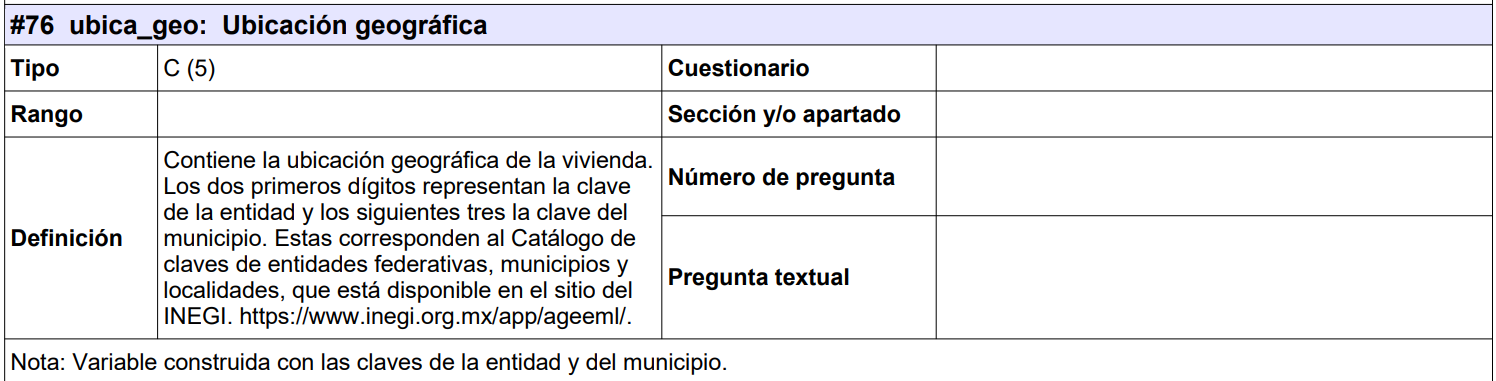

In [7]:
VIVIENDA_edo = VIVIENDA[VIVIENDA['ubica_geo'].astype(str).str.startswith(f'{codigo}')].copy()
VIVIENDA_edo

,folioviv,disp_elect,tot_resid,ubica_geo,factor
9635,401161019,1,2,4001,141
9636,401161020,1,1,4001,141
9637,401161021,1,2,4001,141
9638,401161022,1,4,4001,141
9639,401161024,1,4,4001,141
...,...,...,...,...,...
11824,461430920,3,7,4011,124
11825,461430921,1,1,4011,124
11826,461430922,1,4,4011,124
11827,461430923,1,2,4011,124


# Importar tabla GASTOHOGAR, filtrar gastos de electricidad por vivienda para el estado

In [8]:
f = '../data/raw/enigh2024_ns_gastoshogar_csv/gastoshogar.csv'
GASTOHOGAR = pd.read_csv(f, 
                       usecols = ['folioviv',
                                  'foliohog',
                                  'clave',
                                  # 'mes_dia','fecha_adqu','cantidad', 'gasto', 'costo',
                                  'gasto_tri',
                                  # 'entidad',
                                  'factor'
                                 ]
                      )
GASTOHOGAR

,folioviv,foliohog,clave,gasto_tri,factor
0,100001901,1,011131,167.14,207
1,100001901,1,011150,642.85,207
2,100001901,1,011231,192.85,207
3,100001901,1,011411,488.57,207
4,100001901,1,011460,1465.71,207
...,...,...,...,...,...
5311492,3260593818,1,131208,300,183
5311493,3260593818,1,13120A,210,183
5311494,3260593818,1,13120L,360,183
5311495,3260593818,1,181126,192.85,183


In [9]:
# solo nos quedamos con los que sean de electricidad clave = 045100
GASTOHOGAR_luz = GASTOHOGAR[GASTOHOGAR['clave'] == '045100'].copy()
GASTOHOGAR_luz['gasto_tri'] = pd.to_numeric(GASTOHOGAR_luz['gasto_tri'], errors='coerce')
GASTOHOGAR_luz = GASTOHOGAR_luz.drop(columns = ['foliohog','clave'])

#Vamos a reducir de hogares a viviendas, para ello se sumaran los valores de gasto_tri de todos los hogares de cada vivienda 
GASTOHOGAR_luz = GASTOHOGAR_luz.groupby('folioviv', as_index=False)['gasto_tri'].sum()
GASTOHOGAR_luz

,folioviv,gasto_tri
0,100001901,195.0
1,100001902,900.0
2,100001904,663.0
3,100001905,274.5
4,100002501,481.5
...,...,...
82089,3260593814,180.0
82090,3260593815,450.0
82091,3260593816,420.0
82092,3260593817,180.0


In [10]:
GASTOHOGAR_luz_edo = GASTOHOGAR_luz[GASTOHOGAR_luz['folioviv'].isin(VIVIENDA_edo['folioviv'])].copy()
GASTOHOGAR_luz_edo

,folioviv,gasto_tri
8865,401161020,375.0
8866,401161021,582.0
8867,401161022,727.5
8868,401161024,450.0
8869,401161301,387.0
...,...,...
10891,461430718,0.0
10892,461430920,60.0
10893,461430922,60.0
10894,461430923,75.0


# Obtener edo_df con los datos de VIVIENDA_edo y GASTOHOGAR_luz_edo

In [11]:
VIVIENDA_edo.columns

Index(['folioviv', 'disp_elect', 'tot_resid', 'ubica_geo', 'factor'], dtype='object')

In [12]:
# Merge completo con VIVIENDA_HOGAR_edo y GASTOHOGAR_luz_edo
edo_df = pd.merge(
    VIVIENDA_edo,
    GASTOHOGAR_luz_edo,
    on='folioviv',
    how='outer',   # conserva todos los registros de ambos DataFrames
    indicator=False # opcional, para ver de dónde viene cada fila
)

In [13]:
edo_df.isna().sum()

folioviv        0
disp_elect      0
tot_resid       0
ubica_geo       0
factor          0
gasto_tri     163
dtype: int64

In [14]:
edo_df['gasto_tri']

0         NaN
1       375.0
2       582.0
3       727.5
4       450.0
        ...  
2189     60.0
2190      NaN
2191     60.0
2192     75.0
2193     60.0
Name: gasto_tri, Length: 2194, dtype: float64

In [15]:
edo_df['gasto_men'] = edo_df['gasto_tri']/3
edo_df['gasto_men'] 

0         NaN
1       125.0
2       194.0
3       242.5
4       150.0
        ...  
2189     20.0
2190      NaN
2191     20.0
2192     25.0
2193     20.0
Name: gasto_men, Length: 2194, dtype: float64

In [16]:
edo_df_original = edo_df.copy()
edo_df_original['factor'].sum()

np.int64(270527)

In [17]:
repetidos = edo_df[
    edo_df['folioviv'].duplicated(keep=False)
]
repetidos

,folioviv,disp_elect,tot_resid,ubica_geo,factor,gasto_tri,gasto_men


Esto es para añadir la informacion de la fecha de inicio y fin de la decena de levantamiento (periodo de 10 dias en los que se realizó la encuesta), el gasto trimestral esta normalizado de acuerdo a la decena de levantamiento 

In [18]:
edo_df

,folioviv,disp_elect,tot_resid,ubica_geo,factor,gasto_tri,gasto_men
0,401161019,1,2,4001,141,NaN,NaN
1,401161020,1,1,4001,141,375.0,125.0
2,401161021,1,2,4001,141,582.0,194.0
3,401161022,1,4,4001,141,727.5,242.5
4,401161024,1,4,4001,141,450.0,150.0
...,...,...,...,...,...,...,...
2189,461430920,3,7,4011,124,60.0,20.0
2190,461430921,1,1,4011,124,NaN,NaN
2191,461430922,1,4,4011,124,60.0,20.0
2192,461430923,1,2,4011,124,75.0,25.0


In [19]:
edo_df["decena"] = edo_df["folioviv"].astype(str).str[-3].astype(int)
edo_df

,folioviv,disp_elect,tot_resid,ubica_geo,factor,gasto_tri,gasto_men,decena
0,401161019,1,2,4001,141,NaN,NaN,0
1,401161020,1,1,4001,141,375.0,125.0,0
2,401161021,1,2,4001,141,582.0,194.0,0
3,401161022,1,4,4001,141,727.5,242.5,0
4,401161024,1,4,4001,141,450.0,150.0,0
...,...,...,...,...,...,...,...,...
2189,461430920,3,7,4011,124,60.0,20.0,9
2190,461430921,1,1,4011,124,NaN,NaN,9
2191,461430922,1,4,4011,124,60.0,20.0,9
2192,461430923,1,2,4011,124,75.0,25.0,9


In [20]:
edo_df["decena"].value_counts(dropna=False)

decena
3    254
8    254
5    249
4    249
2    243
6    243
7    237
9    236
0    229
Name: count, dtype: int64

In [21]:
edo_df.dtypes

folioviv        int64
disp_elect      int64
tot_resid       int64
ubica_geo       int64
factor          int64
gasto_tri     float64
gasto_men     float64
decena          int64
dtype: object

Utilizando las fechas de las decenas de levantamiento [] y con las tarifas de CFE por mes para el 2024, podemos saber que precios le correspondieron a cada decena, esto es importante ya que algunos meses de la ENIGH no caen en temporada de verano, donde los precios son más bajos

| Decena             | Valor en la base de datos | Reunión General | Inicio (8 días antes) | Fin (2 días después) |
|--------------------|---------------------------|------------------|------------------------|-----------------------|
| 1                  | 1                         | 19 ago           | 11 ago                 | 21 ago                |
| 2                  | 2                         | 28 ago           | 20 ago                 | 30 ago                |
| 3                  | 3                         | 9 sept           | 1 sept                 | 11 sept               |
| 4                  | 4                         | 17 sept          | 9 sept                 | 19 sept               |
| 5                  | 5                         | 27 sept          | 19 sept                | 29 sept               |
| 6                  | 6                         | 7 oct            | 29 sept                | 9 oct                 |
| 7                  | 7                         | 17 oct           | 9 oct                  | 19 oct                |
| 8                  | 8                         | 28 oct           | 20 oct                 | 30 oct                |
| 9                  | 9                         | 6 nov            | 29 oct                 | 8 nov                 |
| 10                 | 0                         | 19 nov           | 11 nov                 | 21 nov                |
| 11 (Recuperación)  | -                         | 26 nov           | 18 nov                 | 28 nov                |


Utilizando esta tabla, ya no tenemos que asumir que todas las encuestas caen en agosto y septiembre, lo unico que hay que suponer, por ejemplo en la decena 6, es que todas calleron en octubre y ninguna el 29 y 30 de septiembre, asi como en la decena 9, que se asume que ninguna encuesta se hizo en 30 o 31 de octubre, y todas en noviembre


In [22]:
def crear_mes_tarifa(df):
    def mapear_mes(decena):
        if decena in [1, 2]:
            return "agosto"
        elif decena in [3, 4, 5]:
            return "septiembre"
        elif decena in [6, 7, 8]:
            return "octubre"
        elif decena in [9, 0]:
            return "noviembre"
        else:
            return None  # por si hay NaN u otros valores

    df["mes_tarifa"] = df["decena"].apply(mapear_mes)
    return df


In [23]:
edo_df = crear_mes_tarifa(edo_df)
edo_df

,folioviv,disp_elect,tot_resid,ubica_geo,factor,gasto_tri,gasto_men,decena,mes_tarifa
0,401161019,1,2,4001,141,NaN,NaN,0,noviembre
1,401161020,1,1,4001,141,375.0,125.0,0,noviembre
2,401161021,1,2,4001,141,582.0,194.0,0,noviembre
3,401161022,1,4,4001,141,727.5,242.5,0,noviembre
4,401161024,1,4,4001,141,450.0,150.0,0,noviembre
...,...,...,...,...,...,...,...,...,...
2189,461430920,3,7,4011,124,60.0,20.0,9,noviembre
2190,461430921,1,1,4011,124,NaN,NaN,9,noviembre
2191,461430922,1,4,4011,124,60.0,20.0,9,noviembre
2192,461430923,1,2,4011,124,75.0,25.0,9,noviembre


In [24]:
edo_df["decena"].value_counts(dropna=False)

decena
3    254
8    254
5    249
4    249
2    243
6    243
7    237
9    236
0    229
Name: count, dtype: int64

In [25]:
# Comentar

edo_df = edo_df[edo_df['disp_elect'] == 1]
edo_df['factor'].sum()

np.int64(267262)

In [26]:
print(f'Total gastado en Campeche para la energia electrica {(edo_df['gasto_men'] * edo_df['factor']).sum():,}')

Total gastado en Campeche para la energia electrica 99,020,098.83333334


## El IVA corresponde al 16% y el DAP corresponde al 6%, en total de impuestos son 22%

## Cuantos no recibieron subsidio? tarifa DAC

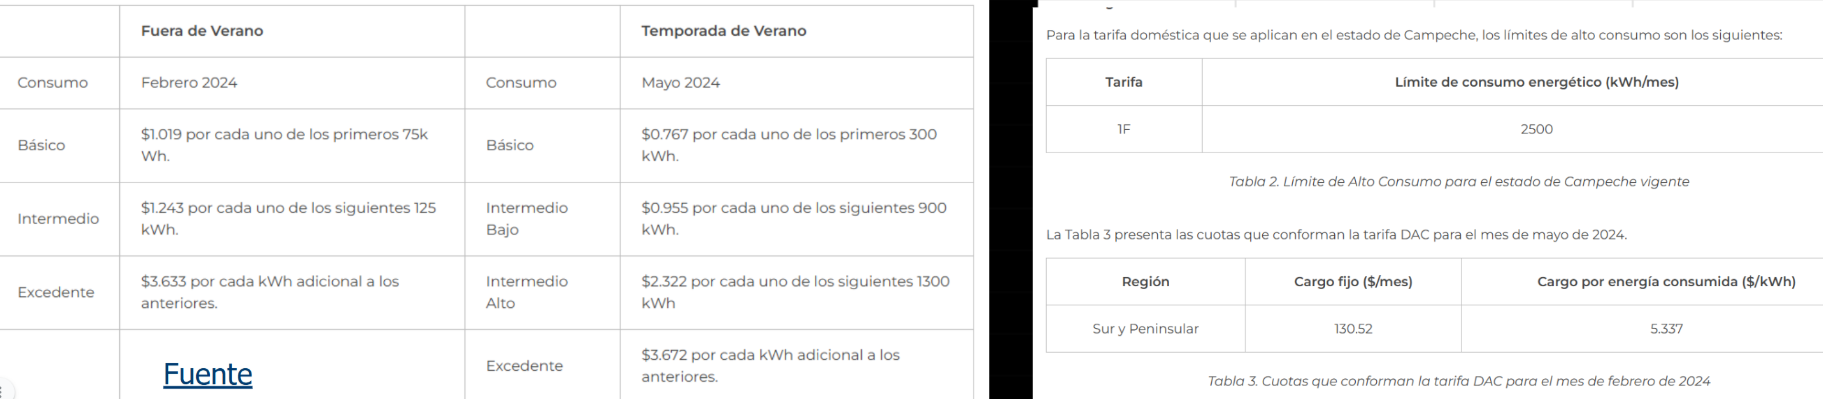

In [27]:
parametros = {
    "agosto": {
        "min_men": 0.776 * 25 * 1.22,
        "basico": 0.776 * 300 * 1.22,
        "intermedio_bajo": 0.964 * 900 * 1.22,
        "intermedio_alto": 2.346 * 1300 * 1.22
    },
    "septiembre": {
        "min_men": 0.779 * 25 * 1.22,
        "basico": 0.779 * 300 * 1.22,
        "intermedio_bajo": 0.967 * 900 * 1.22,
        "intermedio_alto": 2.354 * 1300 * 1.22
    },
    "octubre": {
        "min_men": 1.051 * 25 * 1.22,
        "basico": 1.275 * 75 * 1.22,
        "intermedio": 3.737 * 125 * 1.22,
    },
    "noviembre": {
        "min_men": 1.055 * 25 * 1.22,
        "basico": 1.280 * 75 * 1.22,
        "intermedio": 3.750 * 125 * 1.22,
    }
}
verano = ["agosto","septiembre"]
no_verano = ["octubre","noviembre"]

def get_bloque(row):

    mes = row["mes_tarifa"]

    # Si no existe en el diccionario o es NaN, devolver NaN
    if mes not in parametros:
        return np.nan
    elif mes in verano: 
        # Obtener parámetros del mes
        min_men = parametros[mes]["min_men"]
        basico = parametros[mes]["basico"]
        intermedio_bajo = parametros[mes]["intermedio_bajo"]
        intermedio_alto = parametros[mes]["intermedio_alto"]

        gasto = row["gasto_men"]

        # Clasificación según umbrales del mes correspondiente
        if gasto <= min_men:
            return np.nan
        elif gasto <= basico:
            return "basico"
        elif gasto <= basico + intermedio_bajo:
            return "intermedio_bajo"
        elif gasto <= basico + intermedio_bajo + intermedio_alto:
            return "intermedio_alto"
        else:
            return "DAC"

    elif mes in no_verano: 
        # Obtener parámetros del mes
        min_men = parametros[mes]["min_men"]
        basico = parametros[mes]["basico"]
        intermedio = parametros[mes]["intermedio"]

        gasto = row["gasto_men"]

        # Clasificación según umbrales del mes correspondiente
        if gasto <= min_men:
            return np.nan
        elif gasto <= basico:
            return "basico"
        elif gasto <= basico + intermedio:
            return "intermedio"
        else:
            return "DAC"

In [28]:
edo_df = edo_df.copy()
edo_df["bloque"] = edo_df.apply(get_bloque, axis=1)
edo_df

,folioviv,disp_elect,tot_resid,ubica_geo,factor,gasto_tri,gasto_men,decena,mes_tarifa,bloque
0,401161019,1,2,4001,141,NaN,NaN,0,noviembre,DAC
1,401161020,1,1,4001,141,375.0,125.0,0,noviembre,intermedio
2,401161021,1,2,4001,141,582.0,194.0,0,noviembre,intermedio
3,401161022,1,4,4001,141,727.5,242.5,0,noviembre,intermedio
4,401161024,1,4,4001,141,450.0,150.0,0,noviembre,intermedio
...,...,...,...,...,...,...,...,...,...,...
2187,461430718,1,3,4011,124,0.0,0.0,7,octubre,NaN
2190,461430921,1,1,4011,124,NaN,NaN,9,noviembre,DAC
2191,461430922,1,4,4011,124,60.0,20.0,9,noviembre,NaN
2192,461430923,1,2,4011,124,75.0,25.0,9,noviembre,NaN


## Suponiendo que el subsidio fue planeado de acuerdo a los meses más calidos dentro de la temporada de subsidio, esto solo para los meses que caen en temporada de verano 

In [29]:
verano = ["agosto", "septiembre"]
no_verano = ["octubre", "noviembre"]

suma_no_verano = edo_df.loc[edo_df['mes_tarifa'].isin(no_verano), 'factor'].sum()
suma_verano = edo_df.loc[edo_df['mes_tarifa'].isin(verano), 'factor'].sum()

print(f'''{suma_verano:,} ({round(suma_verano/edo_df['factor'].sum()*100,2):,}%) encuestas en verano y 
{suma_no_verano:,} ({round(suma_no_verano/edo_df['factor'].sum()*100,2):,}%) fuera de verano''')

121,220 (45.36%) encuestas en verano y 
146,042 (54.64%) fuera de verano


In [31]:
# agosto = edo_df.loc[edo_df['mes_tarifa'] == 'agosto', 'factor'].sum()
# septiembre = edo_df.loc[edo_df['mes_tarifa'] == 'septiembre', 'factor'].sum()
# verano = agosto + septiembre

# octubre = edo_df.loc[edo_df['mes_tarifa'] == 'octubre', 'factor'].sum()
# noviembre = edo_df.loc[edo_df['mes_tarifa'] == 'noviembre', 'factor'].sum()
# no_verano = octubre + noviembre

# # print(f''' Hay {bases:,} ({round(bases/viv_calculables*100,2):,}%) vivinedas en bloque basico, 
# # {intermedios:,} ({round(intermedios/viv_calculables*100,2):,}%)en intermedio y {DACs:,} ({round(DACs/viv_calculables*100,2):,}%) en DAC
# #  y {bloque_nan:,} ({round(bloque_nan/viv_calculables*100,2):,}%) sin bloque''')
# tabla = pd.DataFrame({
#     "Mes": ["agosto", "septiembre",'verano', "octubre", "noviembre",'no verano'],
#     "Viviendas": [agosto, septiembre, verano, octubre, noviembre, no_verano],
# })

# tabla["Porcentaje (%)"] = (tabla["Viviendas"] / viv_calculables * 100).round(2)

# # Formato con separador de miles
# tabla["Viviendas"] = tabla["Viviendas"].apply(lambda x: f"{int(x):,}")
# tabla

In [32]:
intermedios = ["intermedio_bajo", "intermedio", 'intermedio_alto']

bases = edo_df.loc[edo_df['bloque'] == 'basico', 'factor'].sum()
intermedios = edo_df.loc[edo_df['bloque'].isin(intermedios), 'factor'].sum()
DACs = edo_df.loc[edo_df['bloque'] == 'DAC', 'factor'].sum()
viv_calculables = edo_df.loc[edo_df['bloque'].notna(), 'factor'].sum()
bloque_nan = edo_df.loc[edo_df['bloque'].isna(), 'factor'].sum()

# print(f''' Hay {bases:,} ({round(bases/viv_calculables*100,2):,}%) vivinedas en bloque basico, 
# {intermedios:,} ({round(intermedios/viv_calculables*100,2):,}%)en intermedio y {DACs:,} ({round(DACs/viv_calculables*100,2):,}%) en DAC
#  y {bloque_nan:,} ({round(bloque_nan/viv_calculables*100,2):,}%) sin bloque''')
tabla = pd.DataFrame({
    "Bloque": ["basico", "intermedios", "DAC", "sin_bloque"],
    "Viviendas": [bases, intermedios, DACs, bloque_nan],
})

tabla["Porcentaje (%)"] = (tabla["Viviendas"] / viv_calculables * 100).round(2)

# Formato con separador de miles
tabla["Viviendas"] = tabla["Viviendas"].apply(lambda x: f"{int(x):,}")
tabla

,Bloque,Viviendas,Porcentaje (%)
0,basico,"82,045",31.72
1,intermedios,"136,588",52.81
2,DAC,"40,007",15.47
3,sin_bloque,"8,622",3.33


In [33]:
edo_df['bloque'].value_counts(dropna=False)

bloque
intermedio         676
basico             655
intermedio_bajo    397
DAC                334
NaN                 67
intermedio_alto     39
Name: count, dtype: int64

Como el subsidio solo corresponde a las viviendas sin tarifa DAC y en verano, hay que ver cuantas son: 

In [34]:
verano = ["agosto", "septiembre"]
no_verano = ["octubre", "noviembre"]

df_no_verano = edo_df.loc[edo_df['mes_tarifa'].isin(no_verano)]
df_verano = edo_df.loc[edo_df['mes_tarifa'].isin(verano)]

bloques = ["basico", "intermedio_bajo", "intermedio", "intermedio_alto"]

# --- Cálculos por temporada ---
tarifa_1F_verano = df_verano.loc[df_verano['bloque'].isin(bloques), 'factor'].sum()
tarifa_1F_no_verano = df_no_verano.loc[df_no_verano['bloque'].isin(bloques), 'factor'].sum()

DACs_verano = df_verano.loc[df_verano['bloque'] == 'DAC', 'factor'].sum()
DACs_no_verano = df_no_verano.loc[df_no_verano['bloque'] == 'DAC', 'factor'].sum()

bloque_nan_verano = df_verano.loc[df_verano['bloque'].isna(), 'factor'].sum()
bloque_nan_no_verano = df_no_verano.loc[df_no_verano['bloque'].isna(), 'factor'].sum()

# --- Totales generales ---
viv_calculables = edo_df.loc[edo_df['bloque'].notna(), 'factor'].sum()
DACs_total = DACs_verano + DACs_no_verano
tarifa_1F_total = tarifa_1F_verano + tarifa_1F_no_verano
bloque_nan_total = bloque_nan_verano + bloque_nan_no_verano

# --- Crear tabla ---
tabla = pd.DataFrame({
    "Categoria": [
        "Tarifa 1F (Verano)", "Tarifa 1F (No Verano)", "Tarifa 1F (Total)",
        "DAC (Verano)", "DAC (No Verano)", "DAC (Total)",
        "Sin bloque (Verano)", "Sin bloque (No Verano)", "Sin bloque (Total)"
    ],
    "Viviendas": [
        tarifa_1F_verano, tarifa_1F_no_verano, tarifa_1F_total,
        DACs_verano, DACs_no_verano, DACs_total,
        bloque_nan_verano, bloque_nan_no_verano, bloque_nan_total
    ]
})

# --- Porcentajes respecto al total calculable ---
tabla["Porcentaje (%)"] = (tabla["Viviendas"] / viv_calculables * 100).round(2)

# --- Formato con separador de miles ---
tabla["Viviendas"] = tabla["Viviendas"].apply(lambda x: f"{int(x):,}")

tabla

,Categoria,Viviendas,Porcentaje (%)
0,Tarifa 1F (Verano),"108,204",41.84
1,Tarifa 1F (No Verano),"110,429",42.70
2,Tarifa 1F (Total),"218,633",84.53
3,DAC (Verano),"9,590",3.71
4,DAC (No Verano),"30,417",11.76
5,DAC (Total),"40,007",15.47
6,Sin bloque (Verano),"3,426",1.32
7,Sin bloque (No Verano),"5,196",2.01
8,Sin bloque (Total),"8,622",3.33


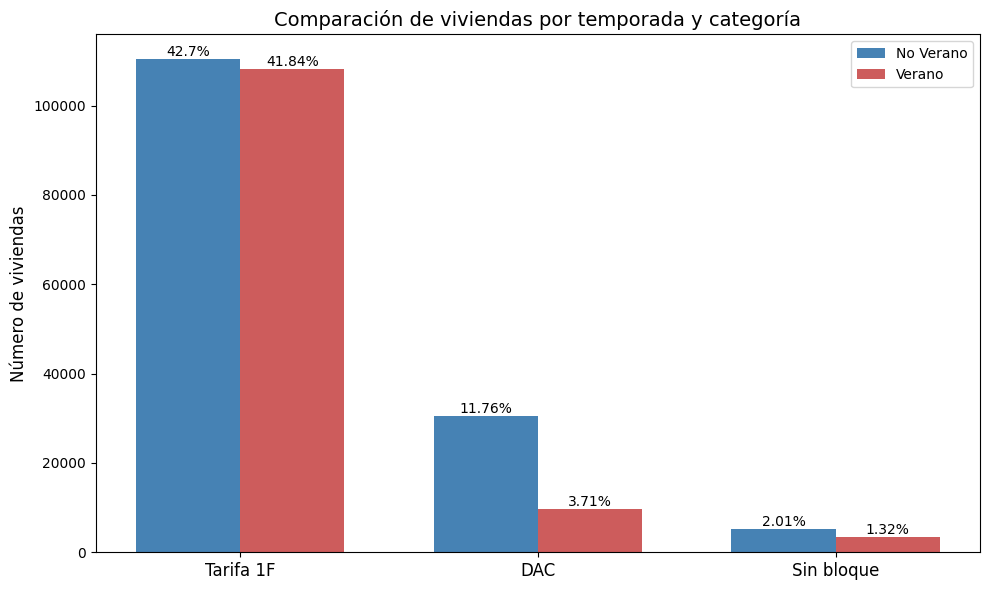

In [35]:
tabla_plot = tabla.copy()
tabla_plot["Viviendas_num"] = tabla_plot["Viviendas"].str.replace(",", "").astype(int)

# Extraer categorías sin los totales
filtros = ["Tarifa 1F", "DAC", "Sin bloque"]

categorias = []
valores_verano = []
valores_no_verano = []
porc_verano = []
porc_no_verano = []

for base in filtros:
    # Buscar filas en la tabla
    verano_row = tabla_plot[tabla_plot["Categoria"] == f"{base} (Verano)"].iloc[0]
    no_verano_row = tabla_plot[tabla_plot["Categoria"] == f"{base} (No Verano)"].iloc[0]

    categorias.append(base)
    valores_verano.append(verano_row["Viviendas_num"])
    valores_no_verano.append(no_verano_row["Viviendas_num"])
    porc_verano.append(verano_row["Porcentaje (%)"])
    porc_no_verano.append(no_verano_row["Porcentaje (%)"])

# --- Preparar gráfico ---
x = np.arange(len(categorias))
width = 0.35

plt.figure(figsize=(10,6))

# Barras
b1 = plt.bar(x - width/2, valores_no_verano, width, label="No Verano", color="steelblue")
b2 = plt.bar(x + width/2, valores_verano, width, label="Verano", color="indianred")

# Etiquetas de porcentaje arriba de cada barra
for i, rect in enumerate(b1):
    plt.text(rect.get_x() + rect.get_width()/2, rect.get_height(),
             f"{porc_no_verano[i]}%", ha="center", va="bottom", fontsize=10)

for i, rect in enumerate(b2):
    plt.text(rect.get_x() + rect.get_width()/2, rect.get_height(),
             f"{porc_verano[i]}%", ha="center", va="bottom", fontsize=10)

# --- Opciones de presentación ---
plt.xticks(x, categorias, fontsize=12)
plt.ylabel("Número de viviendas", fontsize=12)
plt.title("Comparación de viviendas por temporada y categoría", fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

In [36]:
tabla_plot

,Categoria,Viviendas,Porcentaje (%),Viviendas_num
0,Tarifa 1F (Verano),"108,204",41.84,108204
1,Tarifa 1F (No Verano),"110,429",42.70,110429
2,Tarifa 1F (Total),"218,633",84.53,218633
3,DAC (Verano),"9,590",3.71,9590
4,DAC (No Verano),"30,417",11.76,30417
5,DAC (Total),"40,007",15.47,40007
6,Sin bloque (Verano),"3,426",1.32,3426
7,Sin bloque (No Verano),"5,196",2.01,5196
8,Sin bloque (Total),"8,622",3.33,8622


In [37]:
calculables_sin_verano_1F = tabla_plot.loc[tabla_plot['Categoria'] == 'Tarifa 1F (No Verano)', 'Viviendas_num'].sum() + tabla_plot.loc[tabla_plot['Categoria'] == 'DAC (Total)', 'Viviendas_num'].sum()
viv_calculables = edo_df.loc[edo_df['bloque'].notna(), 'factor'].sum()
viv_total = edo_df_original['factor'].sum()

print(f'''Si no consideramos las viviendas en 1F en verano, podemos calcular el consumo de: 
{calculables_sin_verano_1F:,} que es el {round(calculables_sin_verano_1F/viv_calculables*100,2)} % de las que se podian calcular y {round(calculables_sin_verano_1F/viv_total*100,2)}% del original''')

Si no consideramos las viviendas en 1F en verano, podemos calcular el consumo de: 
150,436 que es el 58.16 % de las que se podian calcular y 55.61% del original


In [38]:
viv_total

np.int64(270527)

In [39]:
edo_df['factor'].sum()

np.int64(267262)

In [40]:
df_UTCI = pd.read_csv('../data/modificado/subsidio_UTCI.csv')
df_UTCI = df_UTCI.set_index("nombre_mes")
df_UTCI

,subsidio_area_calida_percent
nombre_mes,
Abril,13.219349
Mayo,19.673003
Junio,13.804607
Julio,19.215726
Agosto,19.731242
Septiembre,14.356073


Con la Tarifa Eléctrica 1F, la más baja del país, los campechanos tendrán un ahorro en los recibos de entre el 20% al 40%, además el Subsidio a la Energía Eléctrica se mantiene por tercer año consecutivo, con una inversión de $72 millones que aplicará del 1 de abril al 30 de septiembre de 2024. https://www.eleconomista.com.mx/politica/La-gobernadora-Layda-Sansores-San-Roman-firmo-el-convenio-para-la-reduccion-del-costo-de-la-energia-electrica-para-todo-el-estado-20231211-0085.html

In [41]:
df_UTCI["subsidio"] = 72000000 * df_UTCI["subsidio_area_calida_percent"] / 100
df_UTCI

,subsidio_area_calida_percent,subsidio
nombre_mes,,
Abril,13.219349,9.517932e+06
Mayo,19.673003,1.416456e+07
Junio,13.804607,9.939317e+06
Julio,19.215726,1.383532e+07
Agosto,19.731242,1.420649e+07
Septiembre,14.356073,1.033637e+07


In [42]:
subsidio_ENIGH = df_UTCI["subsidio"]["Agosto"] + df_UTCI["subsidio"]["Septiembre"]
print(f'Durante la ENIGH solo se recibio subsidio en agosto y septiembre: {round(subsidio_ENIGH,2):,}')

Durante la ENIGH solo se recibio subsidio en agosto y septiembre: 24,542,866.18


CN = CB * 1.22 - S

In [43]:
# Los porcentajes fueron elegidos al tanteo
# Falta quitar los impuestos
# Seria bueno buscar en Hernadez como queda al final la reparticion de subsidio federal en cunato a caracteristicas economicas, 
# y de ahi ver como repartimos el subsidio estatal. O ver si el estado declara que criterios utilizan para repartir el subsidio, si dan 
# un monto para cada bloque o como 

edo_df["subsidio_men"] = 0.0

edo_df.loc[
    (edo_df["bloque"] == "basico"),
    "subsidio_men"
] = edo_df["gasto_men"] * 0.13

edo_df.loc[
    (edo_df["bloque"] == "intermedio_bajo"),
    "subsidio_men"
] = edo_df["gasto_men"] *0.08

edo_df.loc[
    (edo_df["bloque"] == "intermedio_alto"),
    "subsidio_men"
] = edo_df["gasto_men"] *0.05


In [44]:
print(f'{round( (edo_df["factor"] * edo_df["subsidio_men"]).sum() ,2):,}')
print(f'{round(subsidio_ENIGH,2):,}')

4,018,612.28
24,542,866.18


In [45]:
total = edo_df.loc[
edo_df["bloque"].isna() 
| (edo_df["bloque"] == "basico")
| (edo_df["bloque"] == "intermedio_bajo")
| (edo_df["bloque"] == "intermedio_alto")
| (edo_df["bloque"] == "DAC")
, "factor"].sum()

print(f'{round(total,2):,}')

183,333


In [46]:
(edo_df["tot_resid"]*edo_df["factor"]).sum()

np.int64(936197)

In [47]:
edo_df["gasto_men_neto"] = (edo_df["gasto_men"] + edo_df["subsidio_men"])/1.22
edo_df

,folioviv,disp_elect,tot_resid,ubica_geo,factor,gasto_tri,gasto_men,decena,mes_tarifa,bloque,subsidio_men,gasto_men_neto
0,401161019,1,2,4001,141,NaN,NaN,0,noviembre,DAC,0.0,NaN
1,401161020,1,1,4001,141,375.0,125.0,0,noviembre,intermedio,0.0,102.459016
2,401161021,1,2,4001,141,582.0,194.0,0,noviembre,intermedio,0.0,159.016393
3,401161022,1,4,4001,141,727.5,242.5,0,noviembre,intermedio,0.0,198.770492
4,401161024,1,4,4001,141,450.0,150.0,0,noviembre,intermedio,0.0,122.950820
...,...,...,...,...,...,...,...,...,...,...,...,...
2187,461430718,1,3,4011,124,0.0,0.0,7,octubre,NaN,0.0,0.000000
2190,461430921,1,1,4011,124,NaN,NaN,9,noviembre,DAC,0.0,NaN
2191,461430922,1,4,4011,124,60.0,20.0,9,noviembre,NaN,0.0,16.393443
2192,461430923,1,2,4011,124,75.0,25.0,9,noviembre,NaN,0.0,20.491803


In [48]:
def calcular_kWh_men(row):
    if pd.isna(row['bloque']):
        return np.nan
    elif row['bloque'] == 'DAC':
        return (row['gasto_men_neto'] - 130.52) / 5.337
    elif row['bloque'] == 'basico':
        return row['gasto_men_neto'] / 0.767
    elif row['bloque'] == 'intermedio_bajo':
        return (row['gasto_men_neto'] - 300*0.767) / 0.955 + 300
    elif row['bloque'] == 'intermedio_alto':
        return (row['gasto_men_neto'] - 300*0.767 - 900*0.955) / 2.322 + 300 + 900
    else:
        return np.nan  # Por si aparece un valor inesperado en 'bloque'

# Crear la nueva columna kWh_tri
edo_df['kWh_men'] = edo_df.apply(calcular_kWh_men, axis=1)
edo_df

,folioviv,disp_elect,tot_resid,ubica_geo,factor,gasto_tri,gasto_men,decena,mes_tarifa,bloque,subsidio_men,gasto_men_neto,kWh_men
0,401161019,1,2,4001,141,NaN,NaN,0,noviembre,DAC,0.0,NaN,NaN
1,401161020,1,1,4001,141,375.0,125.0,0,noviembre,intermedio,0.0,102.459016,NaN
2,401161021,1,2,4001,141,582.0,194.0,0,noviembre,intermedio,0.0,159.016393,NaN
3,401161022,1,4,4001,141,727.5,242.5,0,noviembre,intermedio,0.0,198.770492,NaN
4,401161024,1,4,4001,141,450.0,150.0,0,noviembre,intermedio,0.0,122.950820,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2187,461430718,1,3,4011,124,0.0,0.0,7,octubre,NaN,0.0,0.000000,NaN
2190,461430921,1,1,4011,124,NaN,NaN,9,noviembre,DAC,0.0,NaN,NaN
2191,461430922,1,4,4011,124,60.0,20.0,9,noviembre,NaN,0.0,16.393443,NaN
2192,461430923,1,2,4011,124,75.0,25.0,9,noviembre,NaN,0.0,20.491803,NaN


In [49]:
edo_df[["folioviv","gasto_men","bloque","subsidio_men","gasto_men_neto","kWh_men"]].to_csv("../data/modificado/luz_Campeche.csv", index=False)

In [50]:
prueba = pd.read_csv("../data/modificado/luz_Campeche.csv")
prueba

,folioviv,gasto_men,bloque,subsidio_men,gasto_men_neto,kWh_men
0,401161019,NaN,DAC,0.0,NaN,NaN
1,401161020,125.0,intermedio,0.0,102.459016,NaN
2,401161021,194.0,intermedio,0.0,159.016393,NaN
3,401161022,242.5,intermedio,0.0,198.770492,NaN
4,401161024,150.0,intermedio,0.0,122.950820,NaN
...,...,...,...,...,...,...
2163,461430718,0.0,NaN,0.0,0.000000,NaN
2164,461430921,NaN,DAC,0.0,NaN,NaN
2165,461430922,20.0,NaN,0.0,16.393443,NaN
2166,461430923,25.0,NaN,0.0,20.491803,NaN


In [51]:
edo_df.dtypes

folioviv            int64
disp_elect          int64
tot_resid           int64
ubica_geo           int64
factor              int64
gasto_tri         float64
gasto_men         float64
decena              int64
mes_tarifa         object
bloque             object
subsidio_men      float64
gasto_men_neto    float64
kWh_men           float64
dtype: object

In [52]:
viv_original = edo_df_original['factor'].sum()
viv_con_consumo = edo_df.loc[edo_df["kWh_men"].notna(), "factor"].sum()
viv_sin_consumo = viv_original - viv_con_consumo

print(f'''Se consiguieron: {round(viv_con_consumo,2):,} ({round(100*viv_con_consumo/viv_original,2):,}%) viviendas con consumo 
y {round(viv_sin_consumo,2):,} ({round(100*viv_sin_consumo/viv_original,2):,}%) viviendas sin consumo ''')


Se consiguieron: 156,178 (57.73%) viviendas con consumo 
y 114,349 (42.27%) viviendas sin consumo 


In [53]:
edo_df_original

,folioviv,disp_elect,tot_resid,ubica_geo,factor,gasto_tri,gasto_men
0,401161019,1,2,4001,141,NaN,NaN
1,401161020,1,1,4001,141,375.0,125.0
2,401161021,1,2,4001,141,582.0,194.0
3,401161022,1,4,4001,141,727.5,242.5
4,401161024,1,4,4001,141,450.0,150.0
...,...,...,...,...,...,...,...
2189,461430920,3,7,4011,124,60.0,20.0
2190,461430921,1,1,4011,124,NaN,NaN
2191,461430922,1,4,4011,124,60.0,20.0
2192,461430923,1,2,4011,124,75.0,25.0


In [54]:
viv_original

np.int64(270527)

In [55]:
viv_con_consumo

np.int64(156178)

In [56]:
edo_df.dtypes

folioviv            int64
disp_elect          int64
tot_resid           int64
ubica_geo           int64
factor              int64
gasto_tri         float64
gasto_men         float64
decena              int64
mes_tarifa         object
bloque             object
subsidio_men      float64
gasto_men_neto    float64
kWh_men           float64
dtype: object

In [57]:
edo_df.loc[edo_df['disp_elect'] != 1, 'factor'].sum()

np.int64(0)

In [58]:
min_men = 0.767 * 25* 1.22
edo_df.loc[edo_df['gasto_men'] < min_men, 'factor'].sum()

np.int64(6489)

In [59]:
edo_df[edo_df['gasto_men'] < min_men]

,folioviv,disp_elect,tot_resid,ubica_geo,factor,gasto_tri,gasto_men,decena,mes_tarifa,bloque,subsidio_men,gasto_men_neto,kWh_men
11,401161507,1,1,4001,141,42.0,14.0,5,septiembre,NaN,0.0,11.475410,NaN
16,401161512,1,5,4001,141,52.5,17.5,5,septiembre,NaN,0.0,14.344262,NaN
79,401164412,1,1,4001,129,0.0,0.0,4,septiembre,NaN,0.0,0.000000,NaN
103,401165406,1,5,4001,108,0.0,0.0,4,septiembre,NaN,0.0,0.000000,NaN
153,401173602,1,1,4002,122,49.5,16.5,6,octubre,NaN,0.0,13.524590,NaN
324,401209804,1,3,4002,122,0.0,0.0,8,octubre,NaN,0.0,0.000000,NaN
540,401254502,1,5,4002,130,0.0,0.0,5,septiembre,NaN,0.0,0.000000,NaN
618,401269204,1,2,4002,141,0.0,0.0,2,agosto,NaN,0.0,0.000000,NaN
631,401271505,1,5,4002,136,0.0,0.0,5,septiembre,NaN,0.0,0.000000,NaN
754,401296804,1,2,4003,126,0.0,0.0,8,octubre,NaN,0.0,0.000000,NaN
